In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image.jpg to image.jpg



Detected Hotspots:
-------------------
Hotspot 1: Area = 387.50, Mean Intensity = 219.47
Hotspot 2: Area = 90.00, Mean Intensity = 217.67
Hotspot 3: Area = 82.00, Mean Intensity = 239.19
Hotspot 4: Area = 252.50, Mean Intensity = 246.11
Hotspot 5: Area = 48.50, Mean Intensity = 252.07
Hotspot 6: Area = 836.50, Mean Intensity = 177.58
Hotspot 7: Area = 37.00, Mean Intensity = 252.95


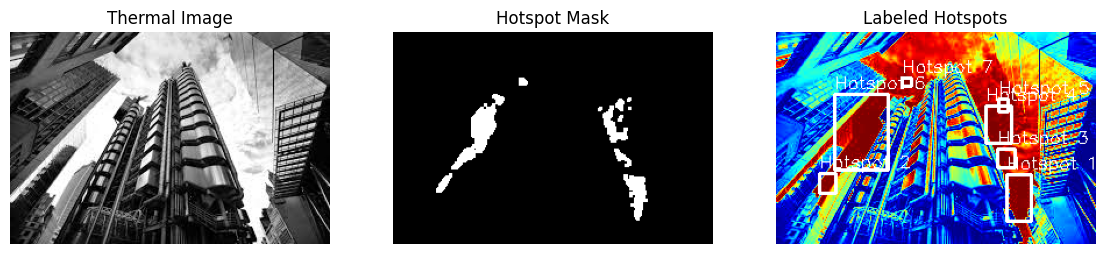

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def thermal_analytics(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Image not loaded. Check file path: {image_path}")
        return
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    thresh_val = np.percentile(blur, 95)
    _, hot_mask = cv2.threshold(blur, int(thresh_val), 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    hot_clean = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    heatmap = cv2.applyColorMap(img, cv2.COLORMAP_JET)
    contours, _ = cv2.findContours(hot_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = heatmap.copy()
    hotspot_id = 1
    print("\nDetected Hotspots:")
    print("-------------------")
    for cnt in contours:
        if cv2.contourArea(cnt) < 20:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        roi = img[y:y+h, x:x+w]
        mean_temp = np.mean(roi)
        cv2.rectangle(output, (x, y), (x+w, y+h), (255, 255, 255), 2)
        cv2.putText(output, f"Hotspot {hotspot_id}", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        print(f"Hotspot {hotspot_id}: Area = {cv2.contourArea(cnt):.2f}, Mean Intensity = {mean_temp:.2f}")
        hotspot_id += 1
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Thermal Image")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(hot_clean, cmap="gray")
    plt.title("Hotspot Mask")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Labeled Hotspots")
    plt.axis("off")
    plt.show()
thermal_analytics("image.jpg")
